# METEOR Description Paper: Seasonal and Noise Model Visualization

This notebook illustrates the capabilities of METEOR for generating ensemble members that combine seasonal patterns with realistic noise structures. We start with a global mean temperature plot comparing a 10-member METEOR ensemble for CESM2 RCP4.5 with the original experiment data.

## 1. Import Required Libraries

In [4]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Third-party imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# METEOR import - import from the correct module
from meteor.meteor import Meteor as METEOR

## 2. Load Model Data from Cache

In [ ]:
# Initialize CMIP6 data getter with cache enabled
from meteor import Cmip6MeteorDataGetter

# Set up the data getter for the experiments we need
# We'll use ssp245 (RCP4.5) along with piControl for the noise model
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["tas"],  # Surface air temperature
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'   ],  # Project names for each experiment
    enable_cache=True  # Use cached data
)

print("Data getter initialized successfully!")
print(f"Available models: {data_getter.get_models_avail()}")

Data getter initialized successfully!
Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


## 4. Calculate Global Mean Temperature

In [12]:
def calculate_global_mean(data):
    """Calculate area-weighted global mean temperature."""
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    return data_weighted.mean(dim=["lat", "lon"])


## 3. Set Up Regional Analysis Tools

In [ ]:
# Install and import regionmask for AR6 regional analysis
try:
    import regionmask
    print("✅ regionmask already installed")
except ImportError:
    print("📦 Installing regionmask...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regionmask", "-q"])
    import regionmask
    print("✅ regionmask installed successfully")

# Load AR6 regions
ar6_regions = regionmask.defined_regions.ar6.all
print(f"✅ AR6 regions loaded: {len(ar6_regions)} regions available")


📦 Installing regionmask...


Python(39512) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ regionmask installed successfully
✅ AR6 regions loaded: 58 regions available

Example regions:


KeyError: slice(None, 5, None)

In [61]:
def calculate_regional_mean(data, region_code):
    """
    Calculate area-weighted regional mean for a specific AR6 region.
    
    Parameters
    ----------
    data : xr.DataArray
        Data with dimensions including 'lat' and 'lon'
    region_code : str
        AR6 region abbreviation (e.g., 'WNA', 'NEU', 'EAS', etc.)
    
    Returns
    -------
    xr.DataArray
        Regional mean time series
    """
    # Create mask for the specified region
    mask = ar6_regions.mask(data)
    
    # Find the region number for the given code
    region_number = None
    for region in ar6_regions:
        if region.abbrev == region_code:
            region_number = region.number
            region_name = region.name
            break
    
    if region_number is None:
        raise ValueError(f"Region code '{region_code}' not found in AR6 regions")
    
    # Apply mask to data
    regional_data = data.where(mask == region_number)
    
    # Calculate area-weighted mean
    weights = np.cos(np.deg2rad(regional_data.lat))
    weights.name = "weights"
    regional_weighted = regional_data.weighted(weights)
    regional_mean = regional_weighted.mean(dim=["lat", "lon"])
    
    # Add attributes
    regional_mean.attrs['region_code'] = region_code
    regional_mean.attrs['region_name'] = region_name
    
    return regional_mean


def list_ar6_regions():
    """List all available AR6 regions with their codes and names."""
    print("AR6 IPCC Reference Regions:")
    print("=" * 60)
    for region in ar6_regions:
        print(f"  {region.abbrev:6s} : {region.name}")
    print("=" * 60)
    print(f"Total: {len(ar6_regions)} regions")



print("\navailable regions:")
list_ar6_regions()


available regions:
AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian

## 5. Set Up Pattern Scaling Models

In [18]:
model_name = "CESM2"
# Import additional METEOR components for pattern scaling
from meteor import MeteorPatternScaling
import sys
from io import StringIO

# Prepare training data dictionary
training_data = {
    "base": data_getter.make_meteor_training_data("base", model_name),
    "co2x4": data_getter.make_meteor_training_data("co2x4", model_name),
    "ssp245": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], model_name)
}

print("Training data prepared:")
for key, data in training_data.items():
    print(f"  {key}: {data['tas'].shape}")
    
# Use ssp245 as the aerosol anomaly experiment (sulxanom)
training_data["sulxanom"] = training_data["ssp245"]

print("\nCreating pattern scaling model with aerosol effects...")

# Suppress stdout during model creation
old_stdout = sys.stdout
sys.stdout = StringIO()

try:
    # Create aerosol-inclusive pattern scaling model
    pattern_model = MeteorPatternScaling(
        f"cmip6-{model_name}-aer",
        {"tas": 2},  # 2 patterns for temperature
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"]
    )
finally:
    # Restore stdout
    sys.stdout = old_stdout

print(f"✅ Pattern scaling model created: {pattern_model.name}")

   Limiting piControl data to first 150 years (was 1200 years)


Training data prepared:
  base: (1, 150, 192, 288)
  co2x4: (1, 999, 192, 288)
  ssp245: (1, 251, 192, 288)

Creating pattern scaling model with aerosol effects...


✅ Pattern scaling model created: cmip6-CESM2-aer


## 6. Load Climate Forcing Data and Generate Predictions

In [19]:
# Load forcing data for SSP245
import os
from ciceroscm import input_handler

# Data directory (adjust path as needed)
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Load concentration and emission data
conc_file = os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
em_file = os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt")

ih = input_handler.InputHandler({})
conc_data = input_handler.read_inputfile(conc_file)
em_data = ih.read_emissions(em_file)

print(f"✅ Forcing data loaded for SSP245")
print(f"   Concentration data: {len(conc_data)} rows")
print(f"   Emission data: {len(em_data)} rows")

# Generate climate prediction using the aerosol-inclusive model
print("\n🌍 Generating climate prediction with aerosol effects...")
climate_prediction = pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["tas"]
)

temperature_prediction = climate_prediction["tas"]
print(f"✅ Climate prediction generated")
print(f"   Temperature shape: {temperature_prediction.shape}")


✅ Forcing data loaded for SSP245
   Concentration data: 801 rows
   Emission data: 751 rows

🌍 Generating climate prediction with aerosol effects...
11
12
113
114
115
22
141
123
142
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)


## 7. Train Noise Model and Generate 10-Member Ensemble

In [ ]:
# Train noise model from CMIP6 data
from meteor.noise_generator import train_noise_model_from_cmip6
from meteor import prpatt

print("🔧 Training noise model for CESM2...")

# Convert annual predictions to monthly
monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
monthly_warming = prpatt.global_mean(monthly_prediction).values

# Skip first 100 years (spin-up)
monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months

# Set up noise cache directory
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")

# Train the noise model
tas_noise_model = train_noise_model_from_cmip6(
    data_getter,
    experiments=["historical", "ssp245"],
    model_name=model_name,
    variable_name="tas",
    n_modes=15,  # Number of PCA modes
    lag_order=2,  # Temporal lag
    custom_global_temp=monthly_warming_trimmed,
    use_picontrol_baseline=True,
    cache_dir=noise_cache_dir
)

print(f"✅ Noise model trained successfully")

print(f"   Training length: {len(monthly_warming_trimmed)//12} years")

🔧 Training noise model for CESM2...
   Limiting piControl data to first 150 years (was 1200 years)
   Limiting piControl data to first 150 years (was 1200 years)
   Fetched piControl baseline for CESM2 tas: 277.318
   Fetched piControl baseline for CESM2 tas: 277.318
Noise generator fitted successfully.
   - PCA modes: 15
   - Variance explained: 63.82%
   - VARX lag order: 2
Noise generator fitted successfully.
   - PCA modes: 15
   - Variance explained: 63.82%
   - VARX lag order: 2
Model saved to /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
✅ Noise model trained successfully
   Modes: 8
   Lag order: 2
   Training length: 251 years
Model saved to /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
✅ Noise model trained successfully
   Modes: 8
   Lag order: 2
   Training length: 251 years


In [67]:
# Generate 10-member ensemble with noise
print("🎲 Generating 10-member METEOR ensemble...")
# Get monthly climatology from training data
monthly_training = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], model_name, monthly=True
)

# Convert to proper monthly coordinates
annual_data = training_data["ssp245"]["tas"]
monthly_base = annual_data.interp(
    year=np.arange(annual_data.year.values[0], annual_data.year.values[-1] + 1/12, 1/12),
    method="linear"
)

# Reassign coordinates to match noise output
n_months = monthly_base.sizes["year"]
monthly_base = monthly_base.assign_coords(month=("year", np.arange(n_months)))
monthly_base = monthly_base.swap_dims({"year": "month"})
monthly_base = monthly_base.drop_vars("year")
n_members = 10
ensemble_members = []

for i in range(n_members):
    print(f"   Generating member {i+1}/{n_members}...")
    
    # Generate noise realization
    noise_realization = tas_noise_model.generate_realization(
        monthly_warming,
        noise_only=True,
        random_seed=42 + i
    )
    

    
    # Combine climatology with noise
    full_realization = noise_realization + monthly_base
    ensemble_members.append(full_realization)

print(f"✅ {n_members}-member ensemble generated")
print(f"   Each member shape: {ensemble_members[0].shape}")
print(f"   Dimensions: {ensemble_members[0].dims}")

🎲 Generating 10-member METEOR ensemble...
   Generating member 1/10...
   Generating member 1/10...
   Generating member 2/10...
   Generating member 2/10...
   Generating member 3/10...
   Generating member 3/10...
   Generating member 4/10...
   Generating member 4/10...
   Generating member 5/10...
   Generating member 5/10...
   Generating member 6/10...
   Generating member 6/10...
   Generating member 7/10...
   Generating member 7/10...
   Generating member 8/10...
   Generating member 8/10...
   Generating member 9/10...
   Generating member 9/10...
   Generating member 10/10...
   Generating member 10/10...
✅ 10-member ensemble generated
   Each member shape: (3002, 192, 288, 1)
   Dimensions: ('month', 'lat', 'lon', 'ens')
✅ 10-member ensemble generated
   Each member shape: (3002, 192, 288, 1)
   Dimensions: ('month', 'lat', 'lon', 'ens')


In [52]:
# Load original CESM2 SSP245 data for comparison
print("📥 Loading original CESM2 SSP245 data from cache...")

ssp245_data = data_getter.make_meteor_training_data_composite(["historical", "ssp245"], model_name,monthly=True)["tas"]


# Also calculate global mean for the original SSP245 data
original_global_mean = calculate_global_mean(ssp245_data)
print(f"✅ Original CESM2 global mean calculated")


📥 Loading original CESM2 SSP245 data from cache...
✅ Original CESM2 global mean calculated
✅ Original CESM2 global mean calculated


## 8. Calculate Global Means and Create Visualization

In [ ]:
# Calculate global means for ensemble members
print("📊 Calculating global means for ensemble members...")

ensemble_global_means = []
for i, member in enumerate(ensemble_members):
    global_mean = calculate_global_mean(member)
    ensemble_global_means.append(global_mean)
    


📊 Calculating global means for ensemble members...
✅ Global means calculated for 10 members
✅ Global means calculated for 10 members
✅ Original CESM2 global mean calculated
   Shape: (1, 251)
✅ Original CESM2 global mean calculated
   Shape: (1, 251)


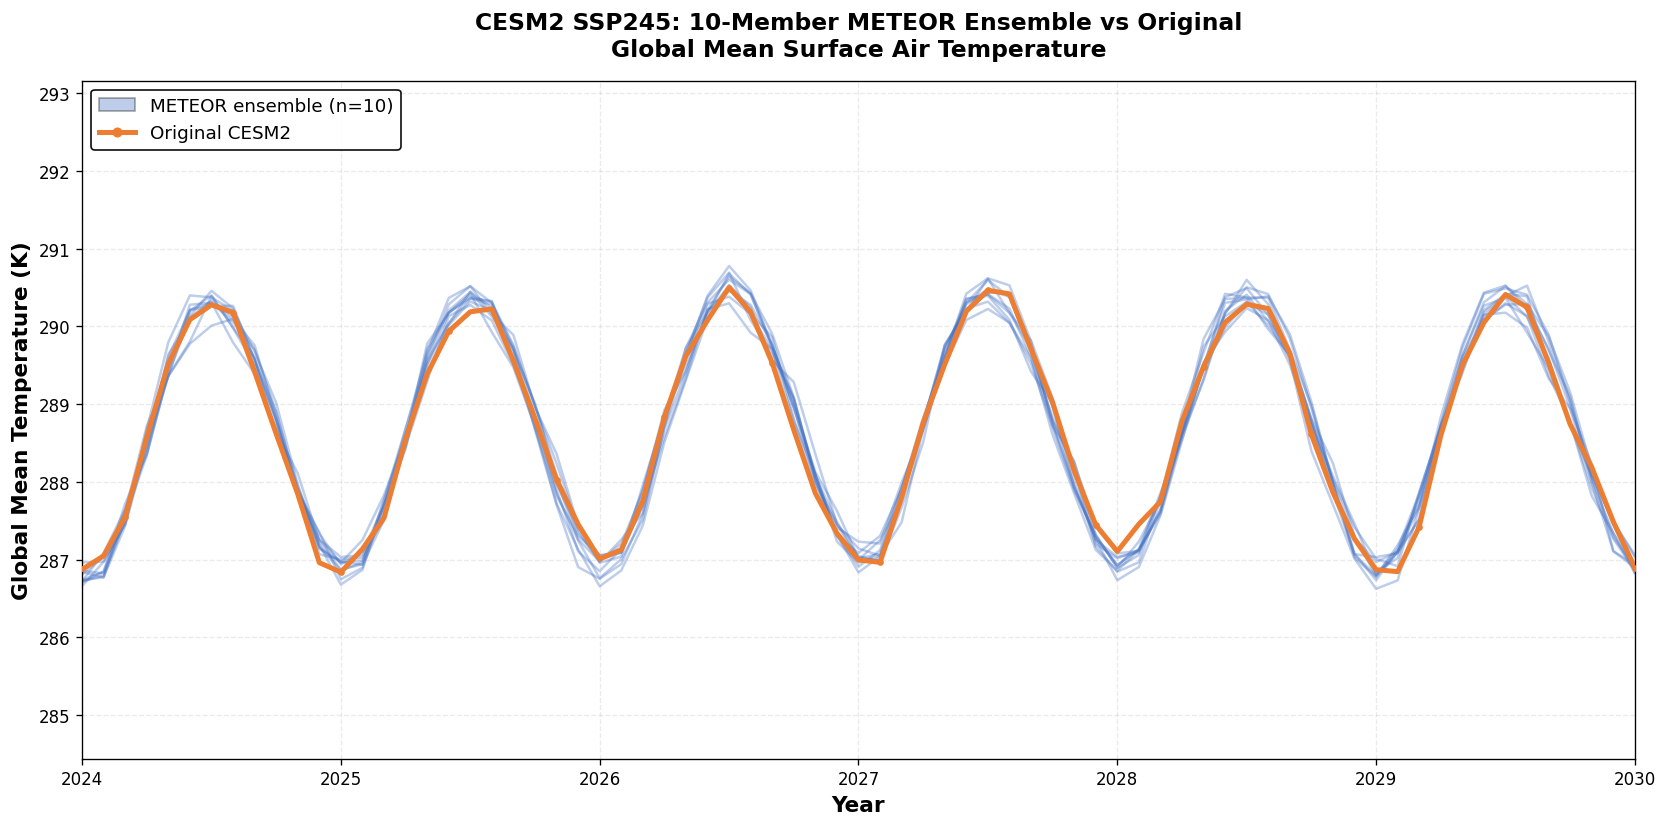

✅ Visualization complete!


In [58]:
# Create the comparison plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# Create time axes
# Ensemble members are in monthly resolution starting from some base year
n_months_ensemble = len(ensemble_global_means[0])
start_year_ensemble = 1850  # Typical CMIP6 start
time_ensemble = start_year_ensemble + np.arange(n_months_ensemble) / 12

# Original data time axis (annual)

# Define colors
ensemble_color = '#4472C4'  # Blue
original_color = '#ED7D31'  # Orange/red

# Plot ensemble members
for i, member_mean in enumerate(ensemble_global_means):
    ax.plot(time_ensemble, member_mean.values, 
            color=ensemble_color, alpha=0.35, linewidth=1.5, 
            label='METEOR ensemble members' if i == 0 else '')
#ssp245_data['year'] = (ssp245_data['month'] / 12) + 1850
# Plot original CESM2 data
ax.plot(ssp245_data['month'].T.values/12+1850, original_global_mean.T.values, 
        color=original_color, linewidth=3, 
        label=f'Original {model_name} SSP245', 
        zorder=10, marker='o', markersize=3, markevery=5)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Global Mean Temperature (K)', fontsize=13, fontweight='bold')
ax.set_title(f'{model_name} SSP245: 10-Member METEOR Ensemble vs Original\nGlobal Mean Surface Air Temperature', 
             fontsize=14, fontweight='bold', pad=15)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ensemble_color, alpha=0.35, edgecolor='black', 
          label=f'METEOR ensemble (n={n_members})'),
    plt.Line2D([0], [0], color=original_color, linewidth=3, marker='o', 
               markersize=5, label=f'Original {model_name}')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', 
          framealpha=0.95, edgecolor='black')

# Set reasonable x-axis limits (focus on future period)
ax.set_xlim(2024, 2030)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [68]:
# Calculate regional means for NEU (Northern Europe)
print("📊 Calculating NEU regional means for ensemble members...")

region_code = "NEU"

# Calculate for ensemble members
ensemble_regional_means = []
for i, member in enumerate(ensemble_members):
    regional_mean = calculate_regional_mean(member, region_code)
    ensemble_regional_means.append(regional_mean)
    print(f"   Member {i+1}/{n_members} complete")

# Calculate for original data
original_regional_mean = calculate_regional_mean(ssp245_data, region_code)
print(f"✅ NEU regional means calculated")
print(f"   Region: {original_regional_mean.attrs['region_name']}")


📊 Calculating NEU regional means for ensemble members...
   Member 1/10 complete
   Member 2/10 complete
   Member 3/10 complete
   Member 4/10 complete
   Member 5/10 complete
   Member 6/10 complete
   Member 7/10 complete
   Member 8/10 complete
   Member 9/10 complete
   Member 10/10 complete
✅ NEU regional means calculated
   Region: N.Europe


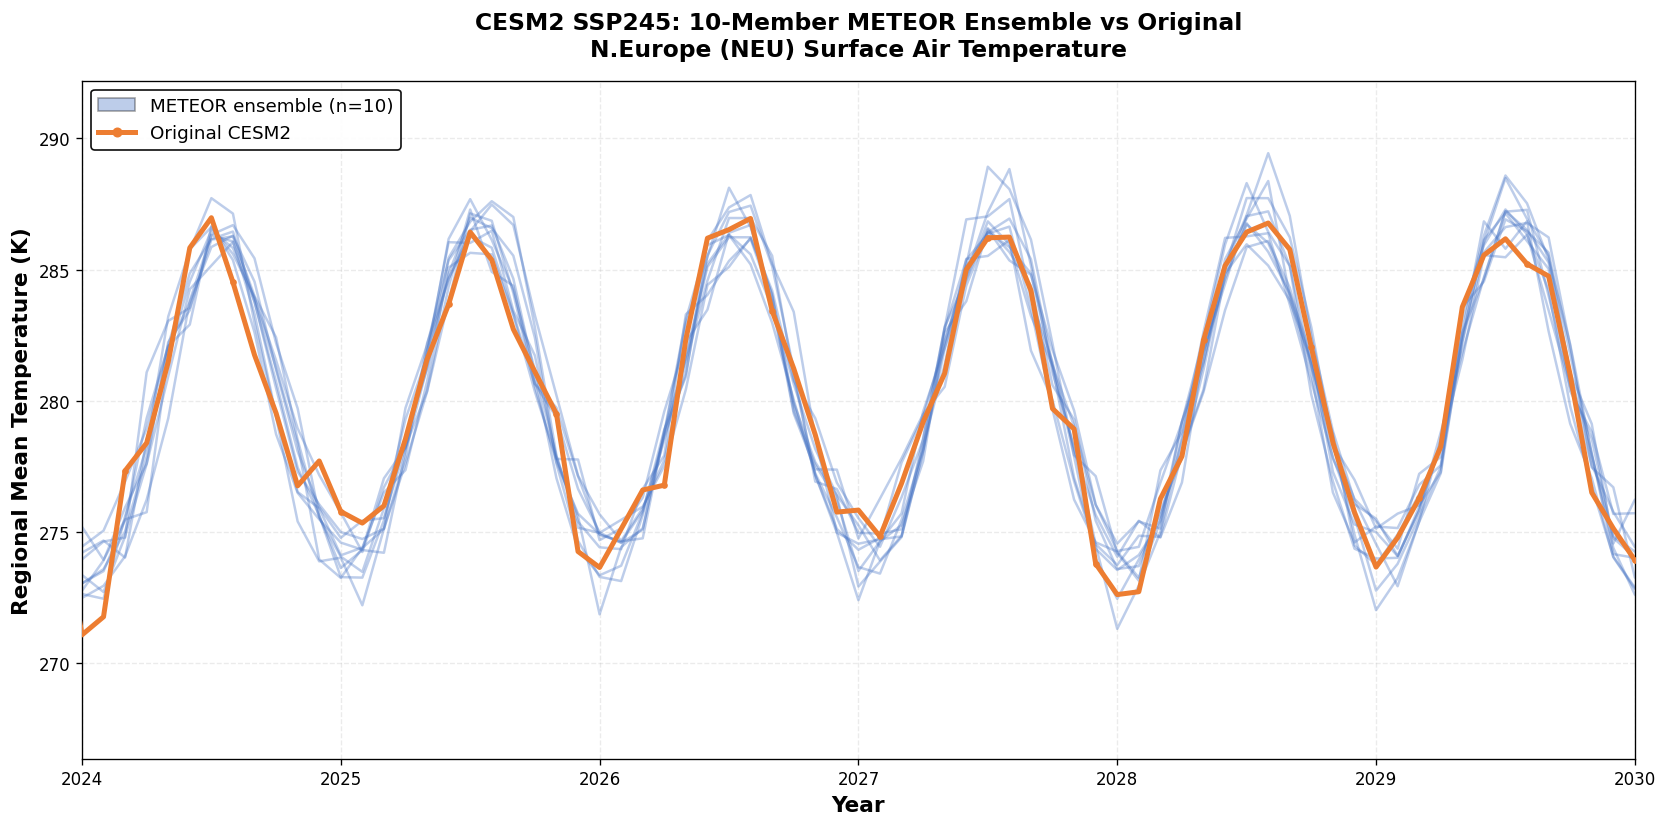

✅ NEU regional visualization complete!


In [69]:
# Create the NEU regional comparison plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# Create time axes (same as global mean plot)
n_months_ensemble = len(ensemble_regional_means[0])
start_year_ensemble = 1850
time_ensemble = start_year_ensemble + np.arange(n_months_ensemble) / 12

# Define colors
ensemble_color = '#4472C4'  # Blue
original_color = '#ED7D31'  # Orange/red

# Plot ensemble members
for i, member_mean in enumerate(ensemble_regional_means):
    ax.plot(time_ensemble, member_mean.values, 
            color=ensemble_color, alpha=0.35, linewidth=1.5, 
            label='METEOR ensemble members' if i == 0 else '')

# Plot original CESM2 data
ax.plot(ssp245_data['month'].values/12 + 1850, original_regional_mean.T.values, 
        color=original_color, linewidth=3, 
        label=f'Original {model_name} SSP245', 
        zorder=10, marker='o', markersize=3, markevery=5)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Regional Mean Temperature (K)', fontsize=13, fontweight='bold')
ax.set_title(f'{model_name} SSP245: 10-Member METEOR Ensemble vs Original\n{original_regional_mean.attrs["region_name"]} ({region_code}) Surface Air Temperature', 
             fontsize=14, fontweight='bold', pad=15)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
legend_elements = [
    Patch(facecolor=ensemble_color, alpha=0.35, edgecolor='black', 
          label=f'METEOR ensemble (n={n_members})'),
    plt.Line2D([0], [0], color=original_color, linewidth=3, marker='o', 
               markersize=5, label=f'Original {model_name}')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', 
          framealpha=0.95, edgecolor='black')

# Set reasonable x-axis limits (focus on future period)
ax.set_xlim(2024, 2030)

plt.tight_layout()
plt.show()

print(f"✅ {region_code} regional visualization complete!")
